# (09) iP-VAE OOD tests

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display


# GitHub
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
sys.path.insert(0, os.path.join(git_dir, 'IterativeVAE'))
from figures.convergence import  plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

## Load iterative VAEs

In [3]:
from base.utils_model import load_model_lite

checkpoints_dir = 'Dropbox/git/IterativeVAE'  # base directory for the project (update to match yours)
checkpoints_dir = add_home(f"{checkpoints_dir}/checkpoints/")  # contains model checkpoints|

In [4]:
print(sorted(
    os.listdir(checkpoints_dir),
    key=alphanum_sort_key,
))

[
    'gaussian+relu_<grad|lin>_vH16-wht_t-16_b-8_k-[512]',
    'gaussian_<grad|lin>_vH16-wht_t-16_b-8_k-[512]',
    'poisson_<grad|lin>_MNIST_t-16_b-12_k-[512]',
    'poisson_<grad|lin>_MNIST_t-64_b-24_k-[512]',
    'poisson_<grad|lin>_vH16-wht_t-16_b-24_k-[512]'
]

In [5]:
f = 'poisson_<grad|lin>_MNIST_t-64_b-24_k-[512]'
tr = load_model_lite(pjoin(checkpoints_dir, f), device=device, verbose=True)[0]
print(tr.model.layer)

# params: 403.2 K

PoissonLayer(input_dim=784, latent_dim=512, temperature=0.01, beta_inner=1, eps=1)

In [6]:
tr.model.print()

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IPVAE    |  403.2 K   |
|     ———     |    ———     |
|    layer    |  403.2 K   |
+-------------+------------+

## Plot dictionary $\Phi$

Learned decoder weights.

100%|███████████████████████████████████| 2/2 [00:09<00:00,  4.88s/it]


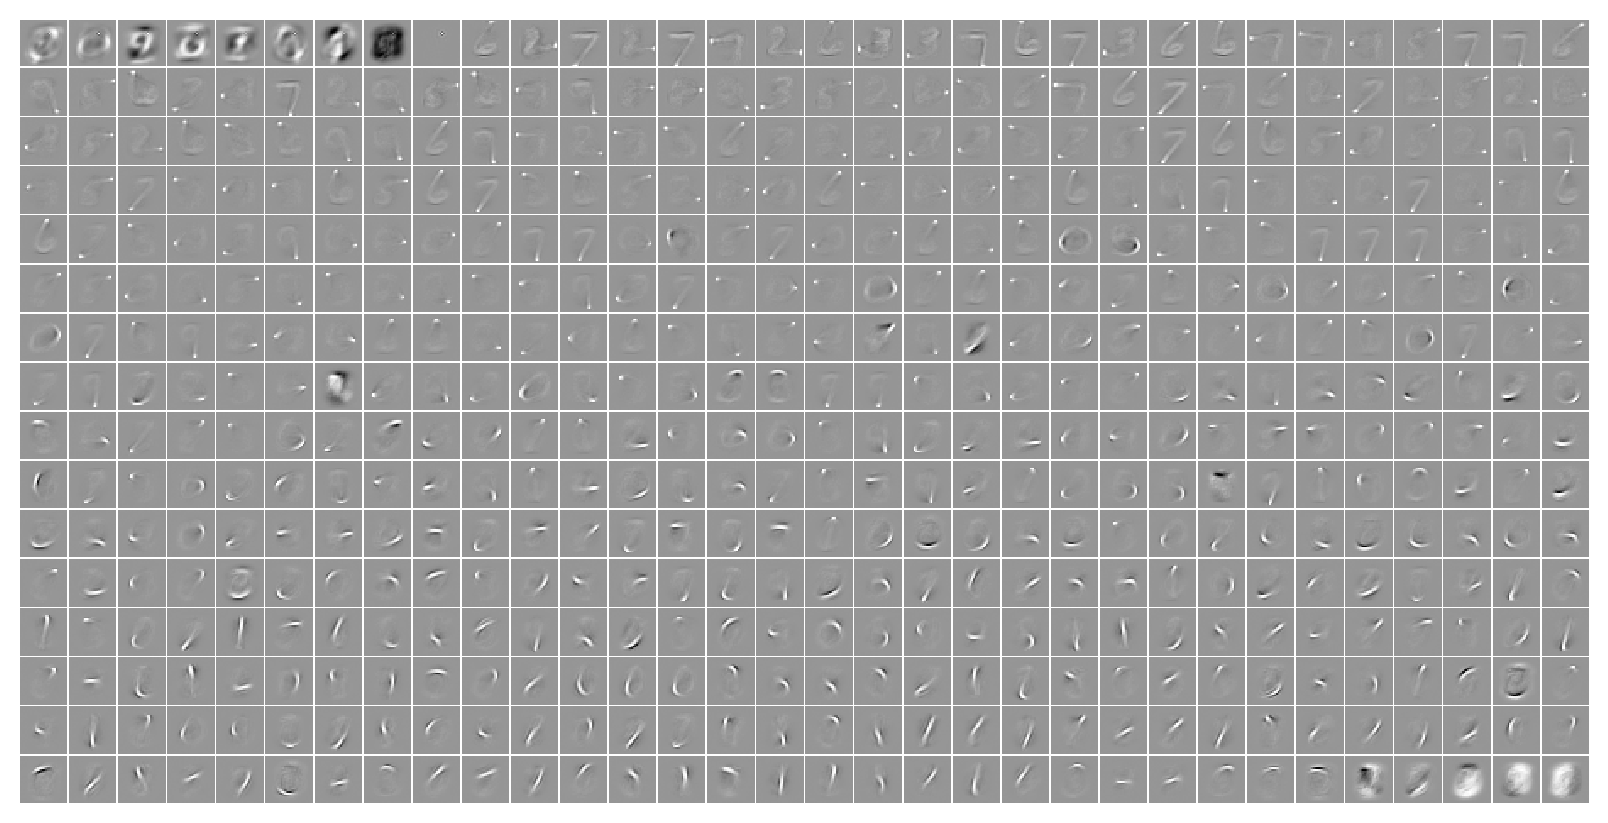

In [7]:
# extract features (we need posterior membrane potentials to sort neurons)
output = tr.xtract_ftr('vld', data_batch_sz=9_000, n_data_batches=-1)
# final membrane potentials averaged over the entire test set
u_final = output['state'][:, -1].mean(0)
# order neurons
order = np.argsort(u_final)
# plot
fig, _ = tr.model.show(order=order, method='abs-max')

## OOD results

In [8]:
from base.dataset import make_dataloader

### Omniglot

In [9]:
trn, vld = make_dataloader('Omniglot', device)

print(f"Train:\t{trn.dataset.tensors[0].shape}\nValid:\t{vld.dataset.tensors[0].shape}")

Train:  torch.Size([19280, 1, 28, 28])
Valid:  torch.Size([13180, 1, 28, 28])

#### OOD: MNIST -> Omni

In [10]:
%%time


t_test = 1_000

num_samples = len(vld.dataset.tensors[0])

output = tr.analysis(
    dl=vld,
    data_batch_sz=int(num_samples / 2),
    n_data_batches=-1,  # full validation set
    t_total=t_test,
)

100%|███████████████████████████████████| 2/2 [00:24<00:00, 12.39s/it]


CPU times: user 54.2 s, sys: 9.88 s, total: 1min 4s
Wall time: 1min 4s


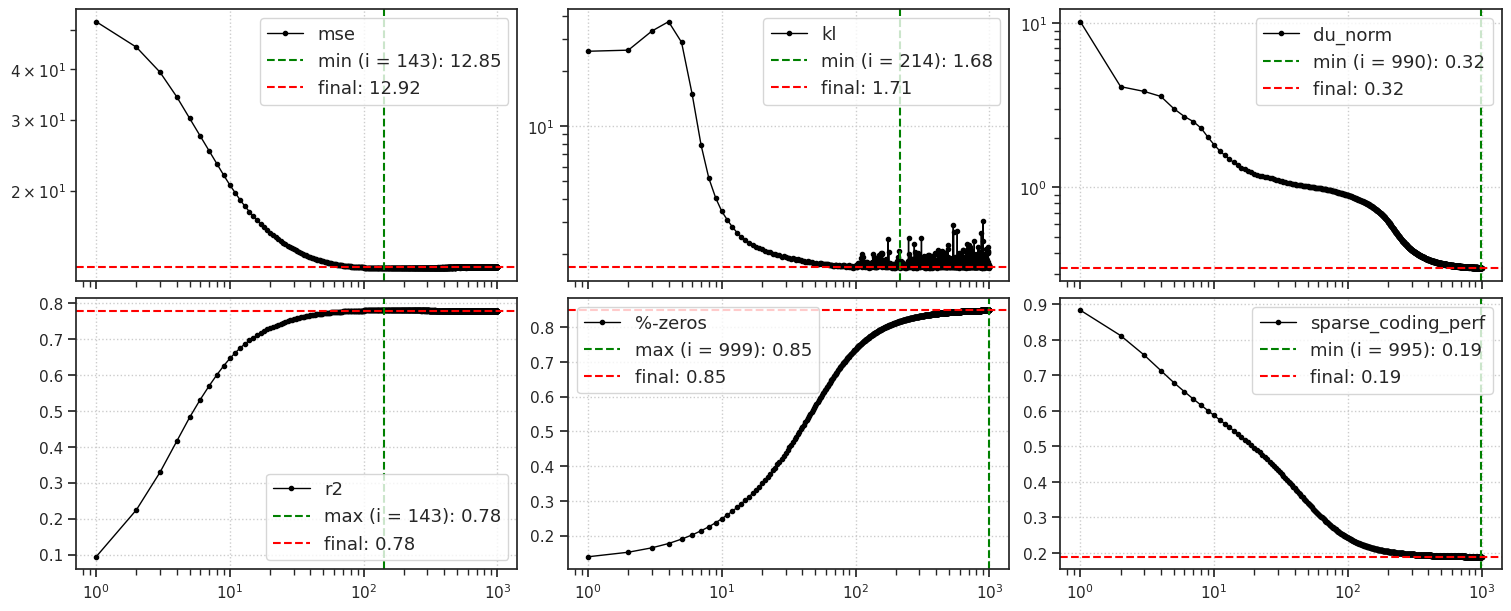

In [11]:
fig, axes = plot_convergence(output, color='k')

In [12]:
list(output)

['kl',
 'r2',
 'mse',
 'nelbo',
 'du_norm',
 'lifetime',
 'population',
 '%-zeros',
 'sparse_coding_perf',
 'state_final',
 'samples_final']

### EMNIST

In [13]:
trn, vld = make_dataloader('EMNIST', device)

print(f"Train:\t{trn.dataset.tensors[0].shape}\nValid:\t{vld.dataset.tensors[0].shape}")

Train:  torch.Size([124800, 1, 28, 28])
Valid:  torch.Size([20800, 1, 28, 28])

#### OOD: MNIST -> EMNIST

In [14]:
%%time


t_test = 1_000

num_samples = len(vld.dataset.tensors[0])

output = tr.analysis(
    dl=vld,
    data_batch_sz=int(num_samples / 2),
    n_data_batches=-1,  # full validation set
    t_total=t_test,
)

100%|███████████████████████████████████| 2/2 [00:33<00:00, 16.52s/it]


CPU times: user 1min 27s, sys: 13.7 s, total: 1min 40s
Wall time: 1min 34s


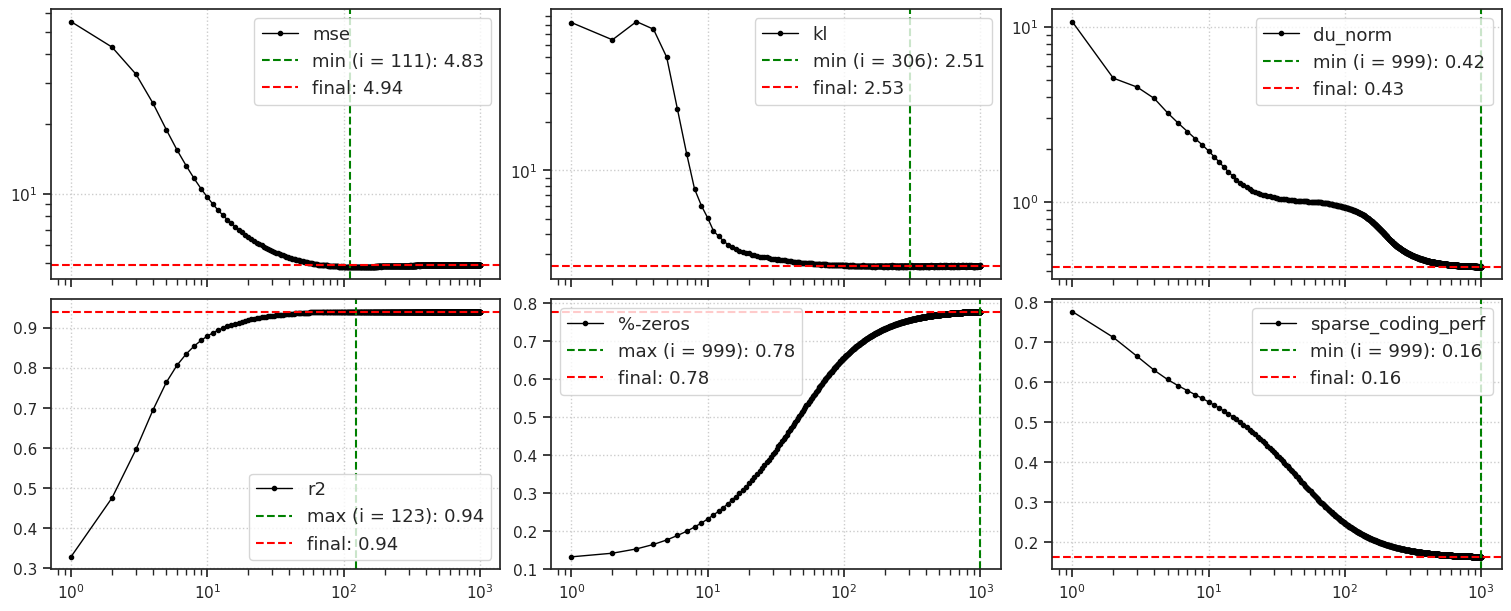

In [15]:
fig, axes = plot_convergence(output, color='k')

## Plot some of the recons

In [16]:
dataset_inds = {
    #
    'MNIST': np.asarray([3, 2, 1, 18, 4, 8, 11, 0, 61, 7]),
    #
    'Omniglot': np.asarray([12710, 5616, 2649, 370, 8713, 9519, 9638, 6146, 9675, 8900, 12934]),
    #
    'EMNIST': np.asarray([1, 2603, 213, 12173, 15308,  6946, 17063, 3510, 4638, 15626, 18359]),
}

train: MNIST  -->  test: MNIST

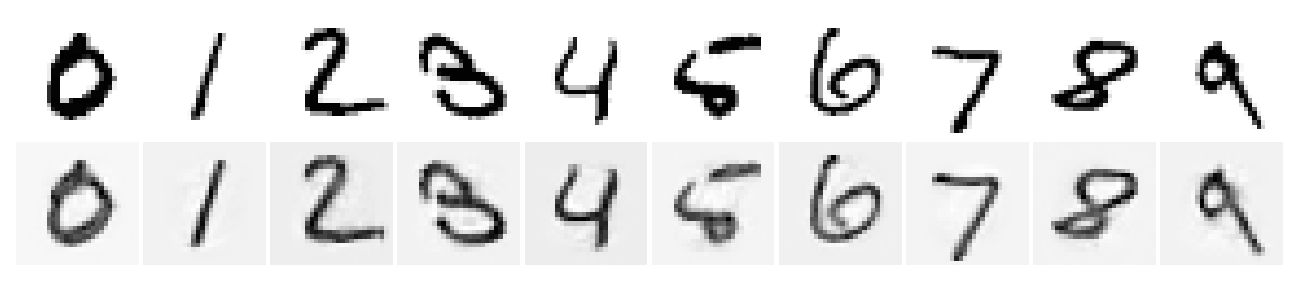

----------------------------------------------------------------------------------------------------

train: MNIST  -->  test: Omniglot

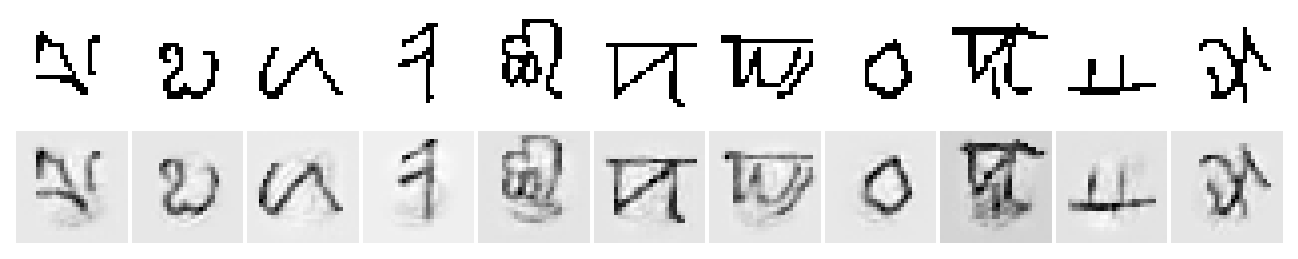

----------------------------------------------------------------------------------------------------

train: MNIST  -->  test: EMNIST

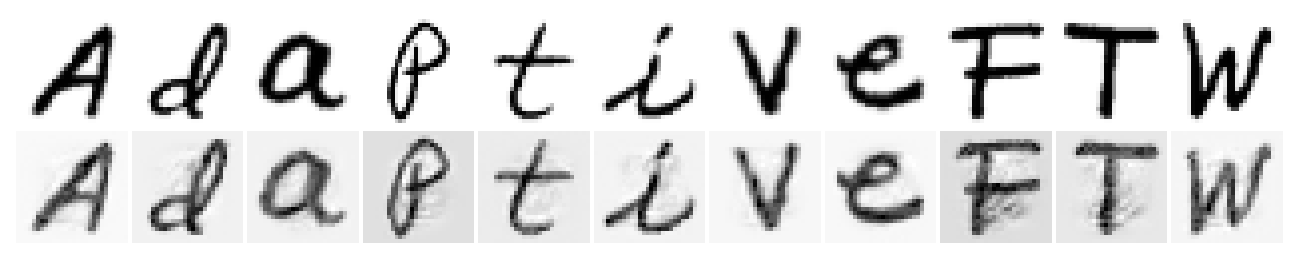

----------------------------------------------------------------------------------------------------

In [17]:
t_total = 1_000

tr.model.eval()

for name, inds in dataset_inds.items():
    x = make_dataset(name, device=device)[1]
    x = x.tensors[0][inds]
    
    # get online datafeeder
    feeder = tr.get_feeder(
        x, seed=tr.model.cfg.seed)

    for t in range(t_total):
        tr.model.update_time(t)
        output = tr.model.xtract_ftr(
            feeder[t], return_extras='recon')

    print(f"train: MNIST  -->  test: {name}")
    x2p = torch.cat([x, output['recon'].reshape(x.shape)])
    fig, axes = plot_weights(x2p, nrows=2, cmap='Greys', method='min-max')
    plt.show()
    print('-' * 100)
    print('\n\n\n')